In [ ]:
!pip install -q sentence-transformers scikit-learn matplotlib seaborn plotly pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
import torch
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
OUT_DIR = Path('/content/drive/MyDrive/AIE_project/outputs')
ML_FEATURES_PATH = OUT_DIR / 'ml_features.csv'           # engineered features (200k rows)
CONV_LABELED_PATH = OUT_DIR / 'conversations_labeled.csv' # clean text, priority, tweet_id
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

In [ ]:
df_feat = pd.read_csv(ML_FEATURES_PATH)
df_text = pd.read_csv(CONV_LABELED_PATH)

print(f"Features shape: {df_feat.shape}")
print(f"Text shape: {df_text.shape}")

# Merge on tweet_id to align features with text and labels
df_merged = df_feat.merge(df_text[['tweet_id', 'text_clean', 'priority']], on='tweet_id', how='inner')
print(f"Merged shape: {df_merged.shape}")

# Drop the priority column from df_feat (now named priority_x) if it exists
if 'priority_x' in df_merged.columns:
    df_merged.drop(columns=['priority_x'], inplace=True)
# Rename priority_y to priority
if 'priority_y' in df_merged.columns:
    df_merged.rename(columns={'priority_y': 'priority'}, inplace=True)

# Define the 10 important features (ensure they exist in df_feat)
important_features = [
    'has_urgency_kw', 'exclamation_count', 'has_time_pressure',
    'char_count', 'sentiment_neg', 'question_mark_count',
    'caps_ratio', 'word_count', 'has_help', 'all_caps_words'
]
# Check which are actually present
available_feats = [f for f in important_features if f in df_merged.columns]
print(f"Using {len(available_feats)} engineered features: {available_feats}")

if len(available_feats) == 0:
    raise ValueError("No engineered features found. Check ml_features.csv columns.")

Features shape: (200000, 12)
Text shape: (200000, 11)
Merged shape: (200000, 14)
Using 10 engineered features: ['has_urgency_kw', 'exclamation_count', 'has_time_pressure', 'char_count', 'sentiment_neg', 'question_mark_count', 'caps_ratio', 'word_count', 'has_help', 'all_caps_words']


In [ ]:
# -------------------------------------------------------------------
# Sample a subset for visualization (stratified by priority)
# -------------------------------------------------------------------
VIZ_SIZE = 5000
df_viz = df_merged.groupby('priority', group_keys=False).apply(
    lambda x: x.sample(min(len(x), VIZ_SIZE // 2), random_state=42)
).reset_index(drop=True)
print(f"Visualization sample: {len(df_viz)} rows (urgent: {(df_viz['priority']==1).sum()}, normal: {(df_viz['priority']==0).sum()})")

# Extract features and labels
X_features = df_viz[available_feats].fillna(0).values
y = df_viz['priority'].values
texts = df_viz['text_clean'].tolist()

# Scale engineered features
scaler = StandardScaler()
X_features_scaled = scaler.fit_transform(X_features)


Visualization sample: 5000 rows (urgent: 2500, normal: 2500)


/tmp/ipykernel_10143/285477036.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
embedder = SentenceTransformer('all-MiniLM-L6-v2', device=device)

print("Generating embeddings from clean text...")
embeddings = embedder.encode(
    texts,
    batch_size=256,
    convert_to_numpy=True,
    normalize_embeddings=True
)
print(f"Embeddings shape: {embeddings.shape}")

# Colors for plots
colors = df_viz['priority'].map({0: 'steelblue', 1: 'tomato'})

Using device: cpu


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings from clean text...
Embeddings shape: (5000, 384)


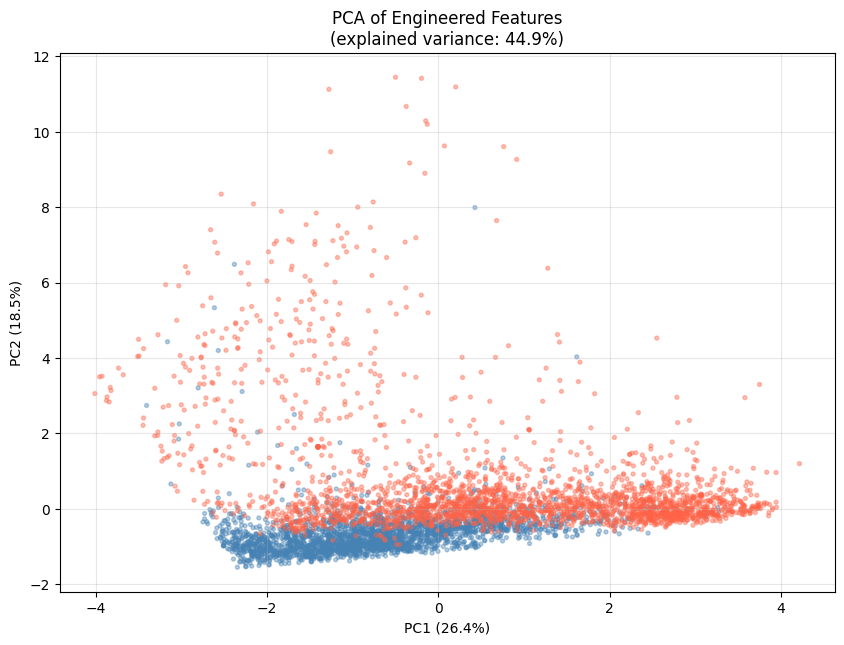

In [ ]:
pca_feat = PCA(n_components=2, random_state=42)
feat_pca = pca_feat.fit_transform(X_features_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(feat_pca[:, 0], feat_pca[:, 1], c=colors, alpha=0.4, s=8)
plt.title(f'PCA of Engineered Features\n(explained variance: {pca_feat.explained_variance_ratio_.sum()*100:.1f}%)')
plt.xlabel(f'PC1 ({pca_feat.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_feat.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(alpha=0.3)
plt.savefig(PLOTS_DIR / 'pca_features.png', dpi=150)
plt.show()

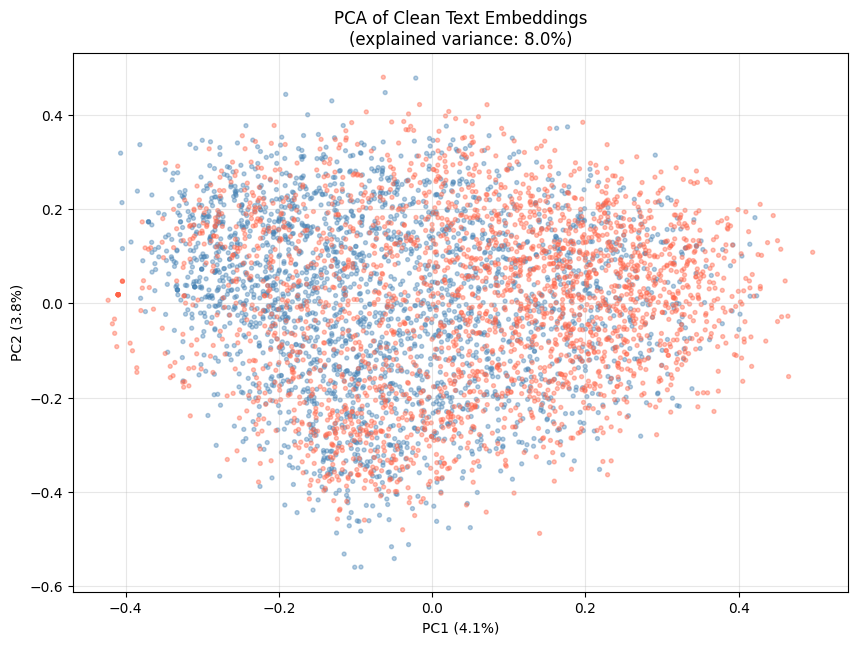

In [ ]:
pca_emb = PCA(n_components=2, random_state=42)
emb_pca = pca_emb.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(emb_pca[:, 0], emb_pca[:, 1], c=colors, alpha=0.4, s=8)
plt.title(f'PCA of Clean Text Embeddings\n(explained variance: {pca_emb.explained_variance_ratio_.sum()*100:.1f}%)')
plt.xlabel(f'PC1 ({pca_emb.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_emb.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(alpha=0.3)
plt.savefig(PLOTS_DIR / 'pca_embeddings.png', dpi=150)
plt.show()

Running t-SNE on engineered features (may take 1-2 minutes)...


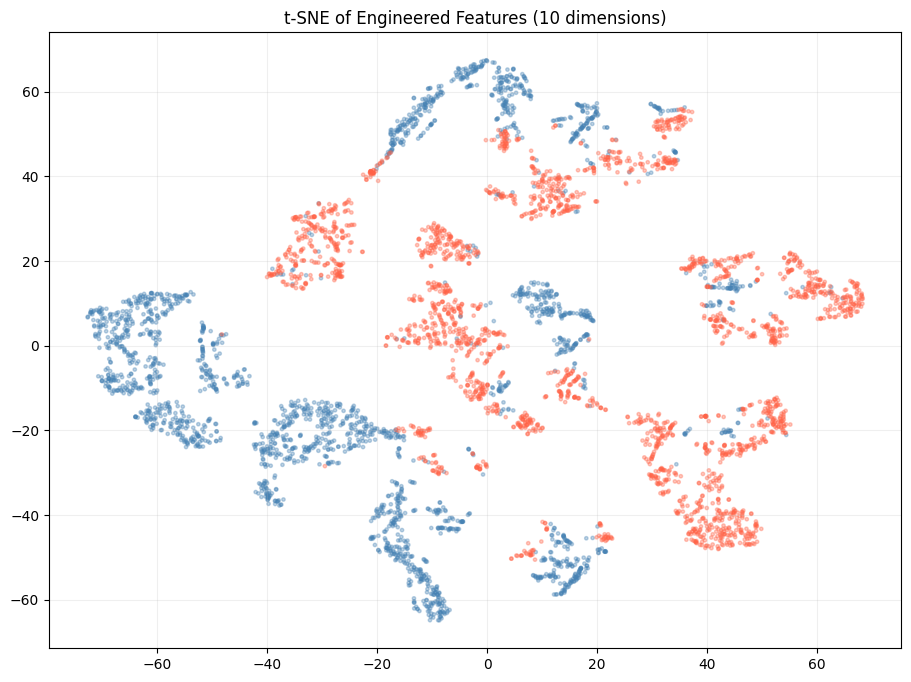

In [ ]:
print("Running t-SNE on engineered features (may take 1-2 minutes)...")
# Since we have only 10 features, we can run t-SNE directly
tsne_feat = TSNE(n_components=2, perplexity=40, learning_rate='auto', init='pca', random_state=42, n_jobs=-1)
feat_tsne = tsne_feat.fit_transform(X_features_scaled)

plt.figure(figsize=(11, 8))
plt.scatter(feat_tsne[:, 0], feat_tsne[:, 1], c=colors, alpha=0.35, s=6)
plt.title('t-SNE of Engineered Features (10 dimensions)')
plt.grid(alpha=0.2)
plt.savefig(PLOTS_DIR / 'tsne_features.png', dpi=150)
plt.show()

In [ ]:
print("Running t-SNE on embeddings (may take 2-3 minutes)...")
pca50_emb = PCA(n_components=50, random_state=42)
reduced_emb = pca50_emb.fit_transform(embeddings)
tsne_emb = TSNE(n_components=2, perplexity=40, learning_rate='auto', init='pca', random_state=42, n_jobs=-1)
emb_tsne = tsne_emb.fit_transform(reduced_emb)

plt.figure(figsize=(11, 8))
plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=colors, alpha=0.35, s=6)
plt.title('t-SNE of Clean Text Embeddings')
plt.grid(alpha=0.2)
plt.savefig(PLOTS_DIR / 'tsne_embeddings.png', dpi=150)
plt.show()

Running t-SNE on embeddings (may take 2-3 minutes)...


In [ ]:
df_plot = pd.DataFrame({
    'x': emb_tsne[:, 0],
    'y': emb_tsne[:, 1],
    'label': df_viz['priority'].map({0: 'Normal', 1: 'Urgent'}),
    'text': [t[:80] + '...' if len(t) > 80 else t for t in texts]
})
fig = px.scatter(df_plot, x='x', y='y', color='label',
                 color_discrete_map={'Urgent': 'tomato', 'Normal': 'steelblue'},
                 hover_data={'text': True}, opacity=0.5,
                 title='t-SNE of Clean Text Embeddings – Hover to read tweet')
fig.write_html(str(PLOTS_DIR / 'tsne_interactive.html'))
fig.show()

print(f"\n✅ All plots saved to {PLOTS_DIR}")
print("\nInterpretation:")
print("  - If embeddings show clear separation between urgent and normal,")
print("    your labeling rule captures genuine linguistic differences.")
print("  - If engineered features also separate, your handcrafted features are meaningful.")
print("  - Better separation in embeddings suggests that raw text contains more signal.")


✅ All plots saved to /content/drive/MyDrive/AIE_project/outputs/plots

Interpretation:
  - If embeddings show clear separation between urgent and normal,
    your labeling rule captures genuine linguistic differences.
  - If engineered features also separate, your handcrafted features are meaningful.
  - Better separation in embeddings suggests that raw text contains more signal.
